# Weekly Quantity Forecasting — Milestone 3: Model Development & Optimization

This notebook implements a full forecasting pipeline for **weekly Quantity** using:
- Classical time-series baselines (Naive, ETS, ARIMA)
- Machine learning models (Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost)
- Pipelines + TimeSeries cross‑validation + hyperparameter tuning

It mirrors the structure of the weekly sales forecasting notebook, but with **Quantity** as the target.

In [76]:
# === Imports ===

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Optional: XGBoost
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("Warning: xgboost is not installed. XGBoost model will be skipped.")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


In [77]:
# === Load weekly features dataset ===
# Update this path if needed

csv_path = "df_technology_weekly_features.csv"

df = pd.read_csv(csv_path)

print("Raw shape:", df.shape)
df.head()


Raw shape: (3323, 29)


,Market,Sub-Category,Year,Week_of_Year,Month,Quarter,Season,Promotion_Flag,Discount,Sales,...,Sales_roll_mean_12,Sales_roll_std_4,Sales_roll_std_12,Quantity_lag_1,Quantity_lag_4,Quantity_lag_12,Quantity_roll_mean_4,Quantity_roll_mean_12,Quantity_roll_std_4,Quantity_roll_std_12
0,APAC,Accessories,2011,17,4,2,Spring,1.0,0.45,659.785500,...,307.570050,253.046208,196.712178,4.0,5.0,10.0,6.50,6.166667,4.509250,4.589184
1,APAC,Accessories,2011,18,5,2,Spring,0.0,0.00,498.390000,...,339.868550,243.849006,193.257041,13.0,3.0,3.0,7.50,6.500000,3.872983,4.482288
2,APAC,Accessories,2011,19,5,2,Spring,0.5,0.25,364.480581,...,333.501932,205.113348,190.870531,7.0,6.0,4.0,10.50,7.666667,6.244998,5.482755
3,APAC,Accessories,2011,21,5,2,Autumn,0.5,0.05,1218.300000,...,413.539432,375.322271,316.374281,18.0,4.0,2.0,14.25,9.083333,5.500000,6.052172
4,APAC,Accessories,2011,22,6,2,Spring,0.4,0.04,1233.352581,...,494.116314,461.929366,390.053650,19.0,13.0,3.0,16.75,10.750000,6.849574,6.916712


In [78]:
# === Basic data inspection ===

df.info()
df.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Market                 3323 non-null   object 
 1   Sub-Category           3323 non-null   object 
 2   Year                   3323 non-null   int64  
 3   Week_of_Year           3323 non-null   int64  
 4   Month                  3323 non-null   int64  
 5   Quarter                3323 non-null   int64  
 6   Season                 3323 non-null   object 
 7   Promotion_Flag         3323 non-null   float64
 8   Discount               3323 non-null   float64
 9   Sales                  3323 non-null   float64
 10  Quantity               3323 non-null   int64  
 11  week_sin               3323 non-null   float64
 12  week_cos               3323 non-null   float64
 13  year_week              3323 non-null   object 
 14  year_week_date         3323 non-null   object 
 15  Sale

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Market,3323,7,APAC,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-Category,3323,4,Phones,968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,3323.0,NaN,NaN,NaN,2012.742401,1.051574,2011.0,2012.0,2013.0,2014.0,2014.0
Week_of_Year,3323.0,NaN,NaN,NaN,29.24827,14.653885,1.0,18.0,31.0,42.0,52.0
Month,3323.0,NaN,NaN,NaN,7.158291,3.353125,1.0,5.0,7.0,10.0,12.0
Quarter,3323.0,NaN,NaN,NaN,2.699368,1.084157,1.0,2.0,3.0,4.0,4.0
Season,3323,4,Autumn,1015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promotion_Flag,3323.0,NaN,NaN,NaN,0.364786,0.397538,0.0,0.0,0.25,0.666667,1.0
Discount,3323.0,NaN,NaN,NaN,0.082465,0.110122,0.0,0.0,0.033333,0.135333,0.5
Sales,3323.0,NaN,NaN,NaN,645.339299,547.674577,10.384,246.490581,492.981162,913.068941,5042.028965


In [79]:
# === Configuration: column names and weekly aggregation ===
# Adjust these if your file uses different names.

DATE_COL = "year_week_date"     # weekly date or week-start date
TARGET_COL = "Sales"            # weekly sales (kept for reference)
PROMO_COL = "Promotion_Flag"    # 0/1 promotion flag
DISCOUNT_COL = "Discount"       # discount level
QTY_COL = "Quantity"            # quantity sold (our target here)

# Convert date column to datetime
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# Aggregate to weekly level (if already weekly, this will just group identical weeks)
weekly = (
    df.groupby(DATE_COL)
      .agg({
          TARGET_COL: "sum",
          PROMO_COL: "mean",
          DISCOUNT_COL: "mean",
          QTY_COL: "sum"
      })
      .reset_index()
      .sort_values(DATE_COL)
)

weekly = weekly.rename(columns={
    DATE_COL: "week_date",
    TARGET_COL: "Sales",
    PROMO_COL: "Promotion_Flag",
    DISCOUNT_COL: "Discount",
    QTY_COL: "Quantity"
})

print("Weekly shape:", weekly.shape)
weekly.head()


Weekly shape: (195, 5)


,week_date,Sales,Promotion_Flag,Discount,Quantity
0,2011-04-04,246.490581,0.000000,0.000000,5
1,2011-04-11,1093.995162,0.500000,0.045000,17
2,2011-04-18,1265.712000,0.750000,0.266667,19
3,2011-04-25,2186.202081,0.479167,0.170833,45
4,2011-05-02,1653.962481,0.375000,0.121250,19


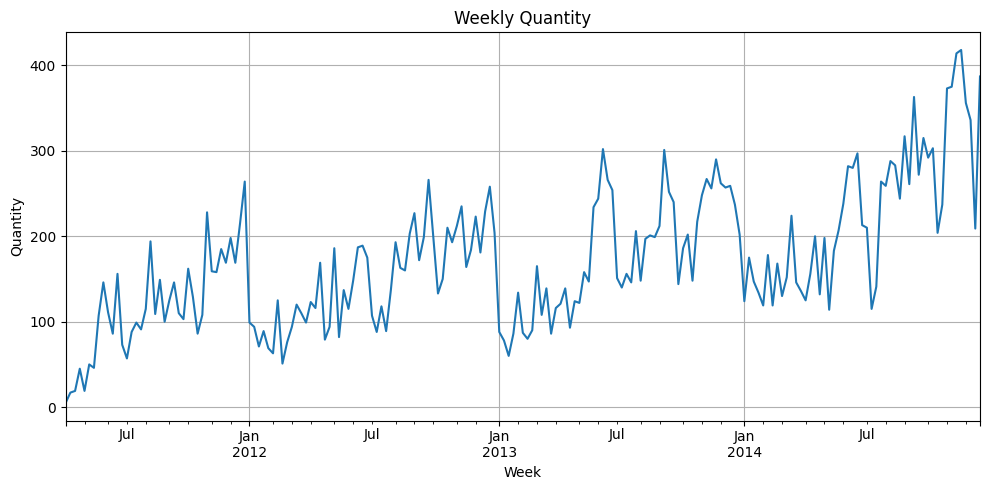

In [80]:
# === Visualize weekly Quantity ===

ax = weekly.set_index("week_date")["Quantity"].plot()
ax.set_title("Weekly Quantity")
ax.set_xlabel("Week")
ax.set_ylabel("Quantity")
plt.tight_layout()
plt.show()


In [81]:
# === Feature engineering for weekly time series (Quantity) ===

# Calendar features
weekly["Year"] = weekly["week_date"].dt.isocalendar().year.astype(int)
weekly["Week_of_Year"] = weekly["week_date"].dt.isocalendar().week.astype(int)
weekly["Month"] = weekly["week_date"].dt.month
weekly["Quarter"] = weekly["week_date"].dt.quarter

# Cyclical encoding for weekly seasonality
weekly["week_sin"] = np.sin(2 * math.pi * weekly["Week_of_Year"] / 52)
weekly["week_cos"] = np.cos(2 * math.pi * weekly["Week_of_Year"] / 52)

# Lag features and rolling means of Quantity (target)
for lag in [1, 2, 4, 12]:
    weekly[f"lag_{lag}"] = weekly["Quantity"].shift(lag)

weekly["roll_mean_4"] = weekly["Quantity"].rolling(4).mean()
weekly["roll_mean_12"] = weekly["Quantity"].rolling(12).mean()

# Drop rows with NaNs introduced by lags/rolling
data = weekly.dropna().reset_index(drop=True)

print("Data for modeling:", data.shape)
data.head()


Data for modeling: (183, 17)


,week_date,Sales,Promotion_Flag,Discount,Quantity,Year,Week_of_Year,Month,Quarter,week_sin,week_cos,lag_1,lag_2,lag_4,lag_12,roll_mean_4,roll_mean_12
0,2011-06-27,6394.615262,0.357143,0.072738,73,2011,26,6,2,-3.216245e-16,-1.000000,156.0,86.0,146.0,5.0,106.50,72.916667
1,2011-07-04,3976.479605,0.590909,0.172000,57,2011,27,7,3,-1.205367e-01,-0.992709,73.0,156.0,111.0,17.0,93.00,76.250000
2,2011-07-11,5655.307205,0.527211,0.115143,88,2011,28,7,3,-2.393157e-01,-0.970942,57.0,73.0,86.0,19.0,93.50,82.000000
3,2011-07-18,5609.562588,0.410256,0.109513,99,2011,29,7,3,-3.546049e-01,-0.935016,88.0,57.0,156.0,45.0,79.25,86.500000
4,2011-07-25,6570.284288,0.500000,0.102013,91,2011,30,7,3,-4.647232e-01,-0.885456,99.0,88.0,73.0,19.0,83.75,92.500000


In [82]:
# === Feature matrix X and target vector y (Quantity) ===

feature_cols = [
    "Promotion_Flag", "Discount",
    "Year", "Week_of_Year", "Month", "Quarter",
    "week_sin", "week_cos",
    "lag_1", "lag_2", "lag_4", "lag_12",
    "roll_mean_4", "roll_mean_12"
]

X = data[feature_cols]
y = data["Quantity"]

# Time-based train/test split (80% train, 20% test)
n = len(data)
train_size = int(0.8 * n)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
dates_train = data["week_date"].iloc[:train_size]
dates_test = data["week_date"].iloc[train_size:]

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (146, 14) Test size: (37, 14)


In [83]:
# === Evaluation helper functions ===

def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
    }

def print_metrics(name, metrics):
    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")


In [84]:
# === Baseline and classical time-series models (Quantity) ===

results = {}
preds_test = {}

# 1) Naive last-week forecast
y_all = y.reset_index(drop=True)
naive_series = y_all.shift(1)
naive_preds = naive_series.iloc[train_size:].values

metrics_naive = eval_metrics(y_test, naive_preds)
print_metrics("Naive (Last Week)", metrics_naive)
results["Naive"] = metrics_naive
preds_test["Naive"] = naive_preds

# 2) Exponential Smoothing (Holt-Winters) on Quantity
train_qty = y_train.astype(float)

ets_model = ExponentialSmoothing(
    train_qty,
    trend="add",
    seasonal="add",
    seasonal_periods=52
)

ets_fit = ets_model.fit(optimized=True)
ets_forecast = ets_fit.forecast(len(y_test))

metrics_ets = eval_metrics(y_test, ets_forecast)
print_metrics("ETS (Holt-Winters)", metrics_ets)
results["ETS"] = metrics_ets
preds_test["ETS"] = ets_forecast

# 3) ARIMA(1,1,1) on Quantity
arima_model = ARIMA(train_qty, order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(y_test))

metrics_arima = eval_metrics(y_test, arima_forecast)
print_metrics("ARIMA(1,1,1)", metrics_arima)
results["ARIMA(1,1,1)"] = metrics_arima
preds_test["ARIMA(1,1,1)"] = arima_forecast



=== Naive (Last Week) ===
MAE: 53.7297
RMSE: 68.6550
MAPE: 0.2363
R2: 0.2749

=== ETS (Holt-Winters) ===
MAE: 51.5521
RMSE: 62.7554
MAPE: 0.2028
R2: 0.3942

=== ARIMA(1,1,1) ===
MAE: 100.5627
RMSE: 119.9194
MAPE: 0.3504
R2: -1.2123


In [85]:
# === Machine Learning models with Pipelines + TimeSeries cross‑validation ===

tscv = TimeSeriesSplit(n_splits=4)

def run_model(name, pipeline, param_grid=None):
    """Fit a pipeline using TimeSeriesSplit CV and evaluate on the hold‑out test set."""
    if param_grid is not None and len(param_grid) > 0:
        gs = GridSearchCV(
            pipeline,
            param_grid,
            cv=tscv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        )
        gs.fit(X_train, y_train)
        best_model = gs.best_estimator_
        print(f"{name} - Best params: {gs.best_params_}")
        print(f"{name} - Best CV MAE: {-gs.best_score_:.2f}\n")
    else:
        best_model = pipeline
        best_model.fit(X_train, y_train)

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    preds_test[name] = y_pred
    metrics = eval_metrics(y_test, y_pred)
    print_metrics(name, metrics)
    results[name] = metrics

# 1) Decision Tree Regressor
pipe_dt = Pipeline([
    ("model", DecisionTreeRegressor(random_state=42))
])
param_dt = {
    "model__max_depth": [3, 5, 7, None],
    "model__min_samples_leaf": [1, 5, 10]
}
run_model("Decision Tree", pipe_dt, param_dt)

# 2) Random Forest Regressor
pipe_rf = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])
param_rf = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["auto", "sqrt", 0.5]
}
run_model("Random Forest", pipe_rf, param_rf)

# 3) Gradient Boosting Regressor
pipe_gbr = Pipeline([
    ("model", GradientBoostingRegressor(random_state=42))
])
param_gbr = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.01, 0.03, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.7, 1.0]
}
run_model("Gradient Boosting", pipe_gbr, param_gbr)

# 4) XGBoost Regressor (if available)
if XGB_AVAILABLE:
    pipe_xgb = Pipeline([
        ("model", XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ])
    param_xgb = {
        "model__n_estimators": [300, 600],
        "model__learning_rate": [0.01, 0.03, 0.05],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.6, 0.9],
        "model__colsample_bytree": [0.6, 0.9],
        "model__reg_alpha": [0, 0.1, 1],
        "model__reg_lambda": [1, 4]
    }
    run_model("XGBoost", pipe_xgb, param_xgb)
else:
    print("Skipping XGBoost: XGBRegressor is not available.")


Decision Tree - Best params: {'model__max_depth': 3, 'model__min_samples_leaf': 10}
Decision Tree - Best CV MAE: 35.71


=== Decision Tree ===
MAE: 59.2164
RMSE: 78.8467
MAPE: 0.2052
R2: 0.0436


c:\Users\mohammed kadry\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
72 fits failed out of a total of 216.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
62 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\mohammed kadry\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mohammed kadry\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
 

Random Forest - Best params: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__n_estimators': 600}
Random Forest - Best CV MAE: 32.08


=== Random Forest ===
MAE: 57.3819
RMSE: 73.5844
MAPE: 0.2045
R2: 0.1670
Gradient Boosting - Best params: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 400, 'model__subsample': 0.7}
Gradient Boosting - Best CV MAE: 30.85


=== Gradient Boosting ===
MAE: 56.5605
RMSE: 70.5463
MAPE: 0.2056
R2: 0.2344
XGBoost - Best params: {'model__colsample_bytree': 0.6, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__reg_alpha': 1, 'model__reg_lambda': 1, 'model__subsample': 0.9}
XGBoost - Best CV MAE: 31.37


=== XGBoost ===
MAE: 58.7089
RMSE: 74.5869
MAPE: 0.2099
R2: 0.1442


In [86]:
# === Compare all models (Quantity) ===

results_df = (
    pd.DataFrame(results)
      .T[["MAE", "RMSE", "MAPE", "R2"]]
      .sort_values("RMSE")
)

results_df


,MAE,RMSE,MAPE,R2
ETS,51.552052,62.755390,0.202846,0.394153
Naive,53.729730,68.655033,0.236264,0.274887
Gradient Boosting,56.560487,70.546326,0.205596,0.234387
Random Forest,57.381937,73.584403,0.204482,0.167024
XGBoost,58.708885,74.586903,0.209937,0.144173
Decision Tree,59.216386,78.846714,0.205239,0.043626
"ARIMA(1,1,1)",100.562733,119.919363,0.350363,-1.212276


Best model by RMSE: ETS


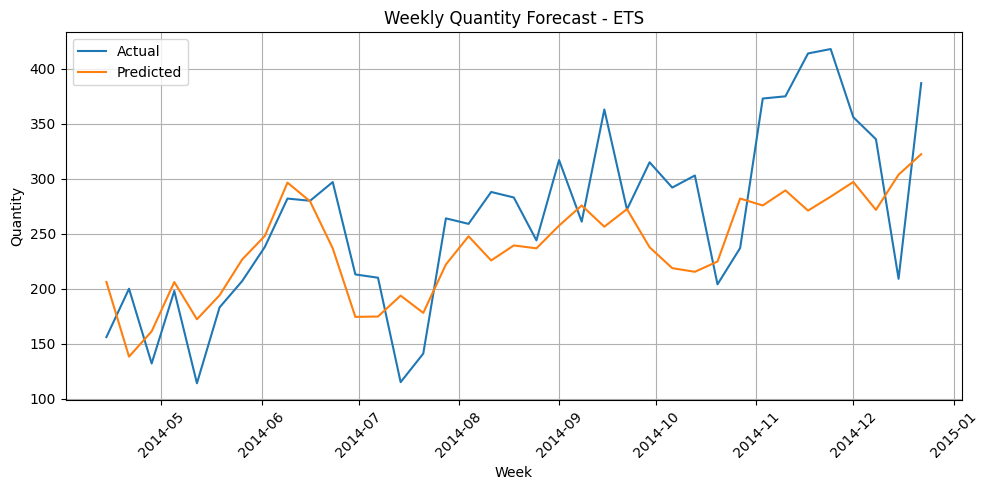

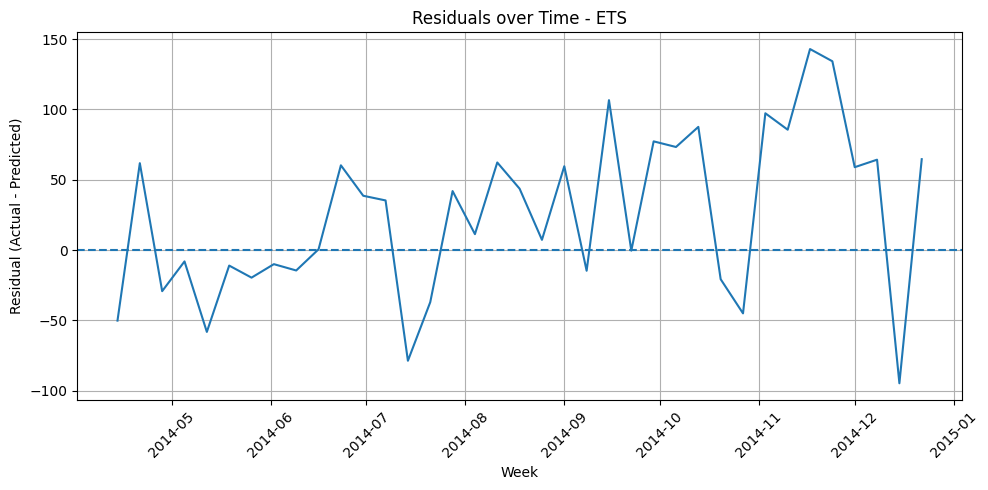

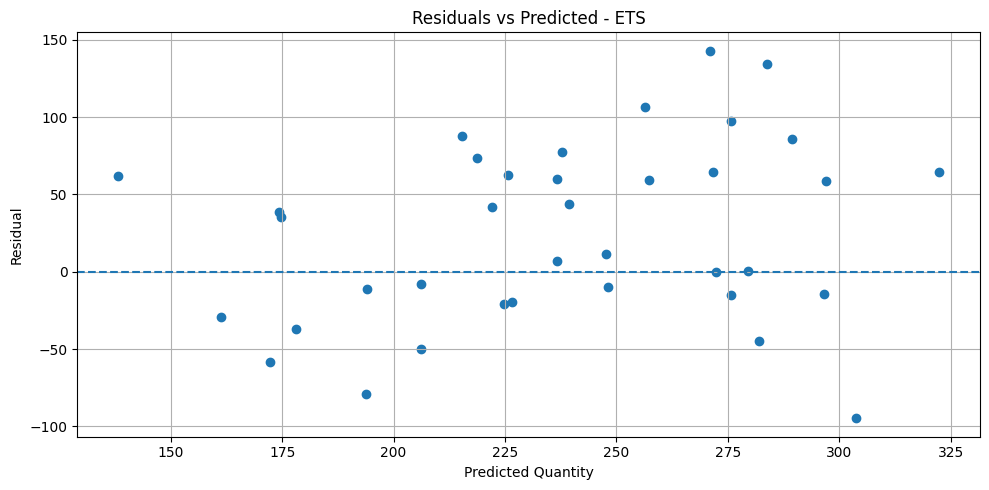

In [87]:
# === Actual vs predicted and residual analysis for the best model ===

# Choose best model by RMSE (lower is better)
best_name = min(results, key=lambda k: results[k]["RMSE"])
print("Best model by RMSE:", best_name)

best_pred = preds_test[best_name]
best_residuals = y_test - best_pred

# Actual vs predicted
plt.figure()
plt.plot(dates_test, y_test.values, label="Actual")
plt.plot(dates_test, best_pred, label="Predicted")
plt.title(f"Weekly Quantity Forecast - {best_name}")
plt.xlabel("Week")
plt.ylabel("Quantity")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Residuals over time
plt.figure()
plt.plot(dates_test, best_residuals)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals over Time - {best_name}")
plt.xlabel("Week")
plt.ylabel("Residual (Actual - Predicted)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Residuals vs predicted
plt.figure()
plt.scatter(best_pred, best_residuals)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals vs Predicted - {best_name}")
plt.xlabel("Predicted Quantity")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


=== Naive ===


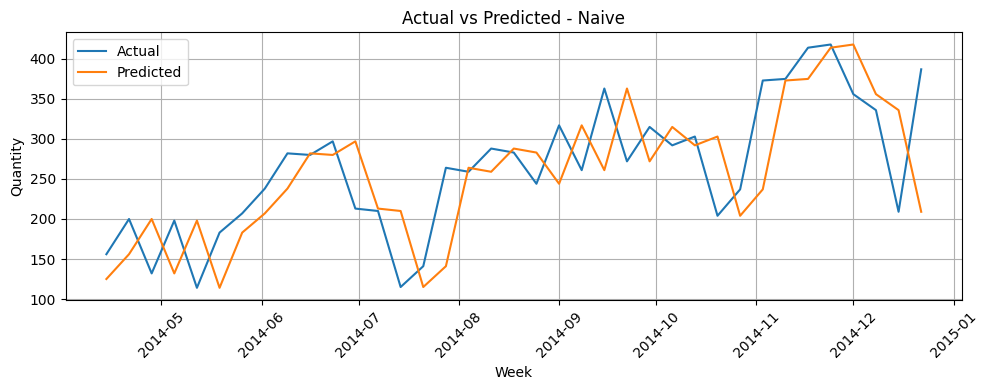

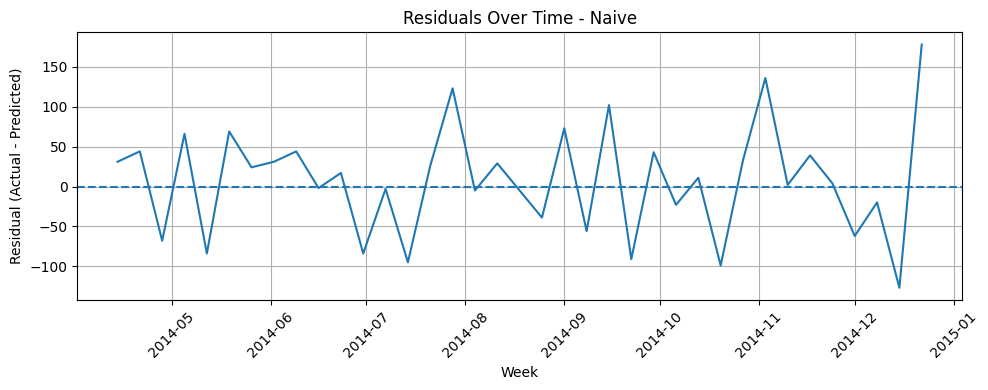

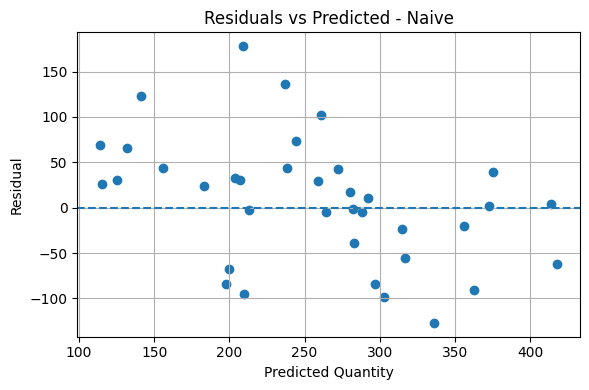

=== ETS ===


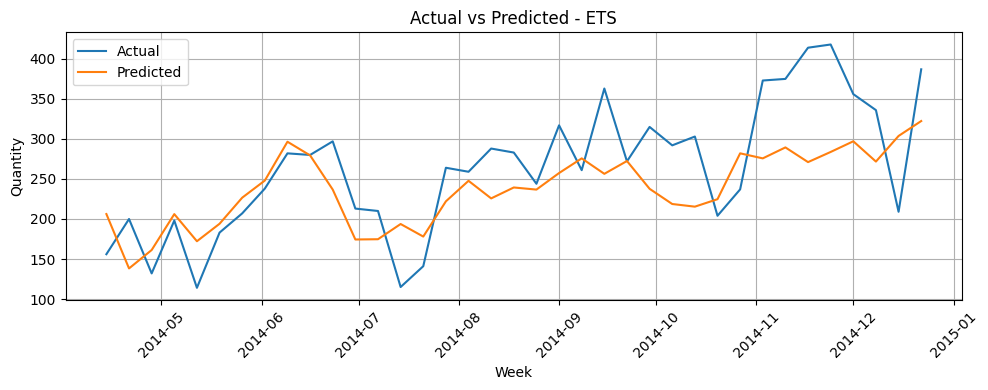

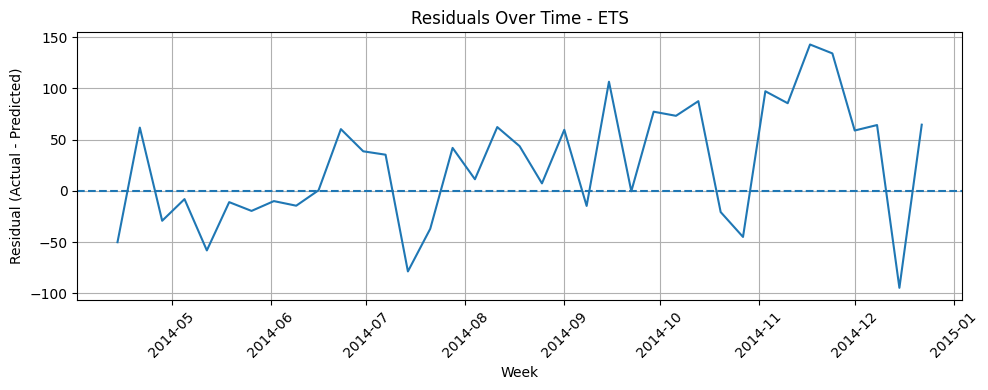

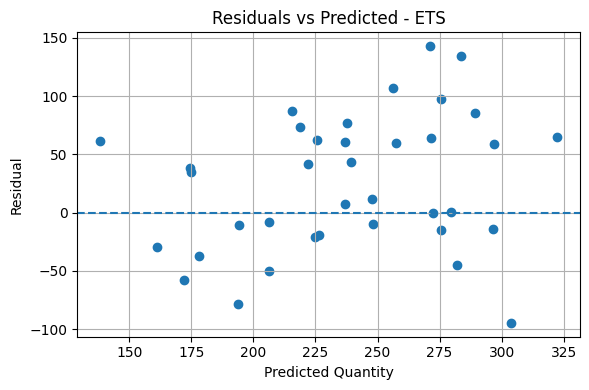

=== ARIMA(1,1,1) ===


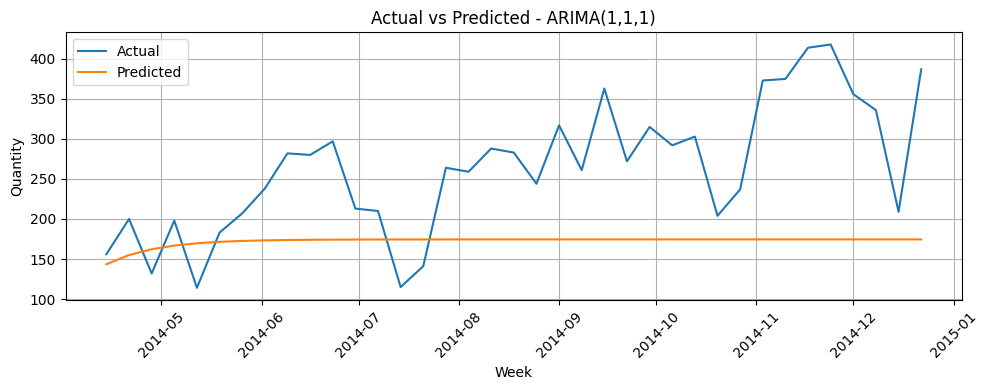

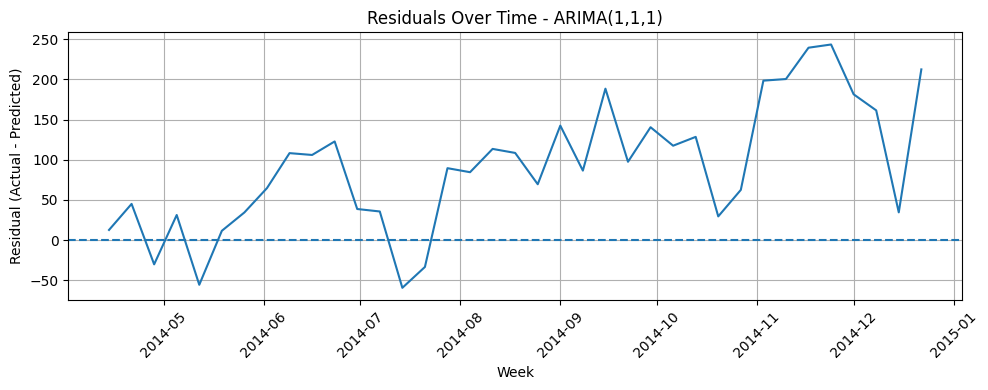

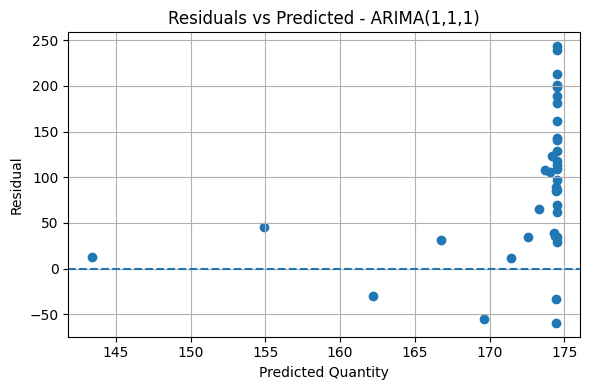

=== Decision Tree ===


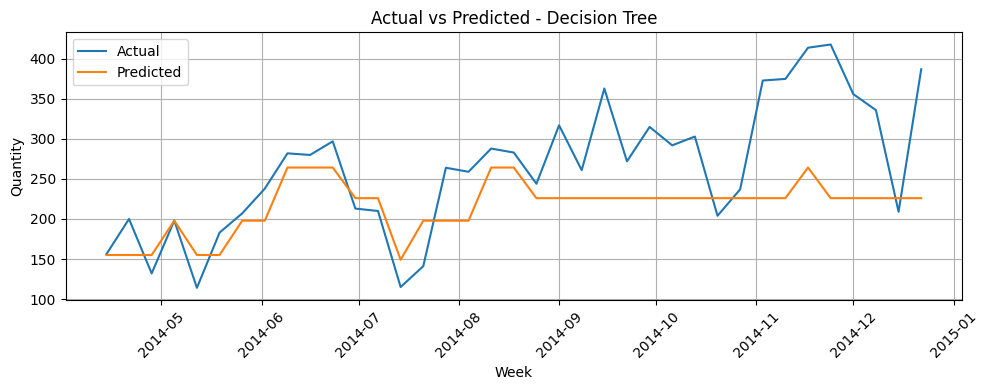

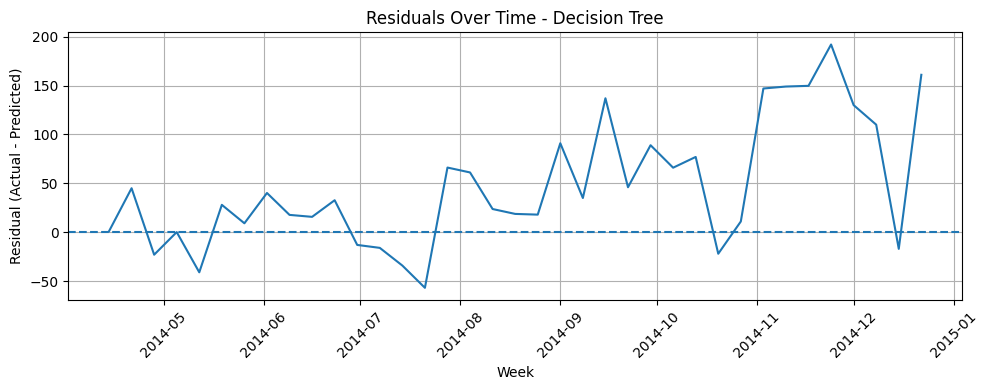

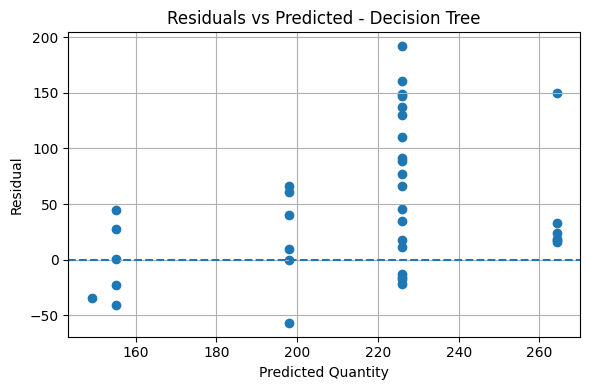

=== Random Forest ===


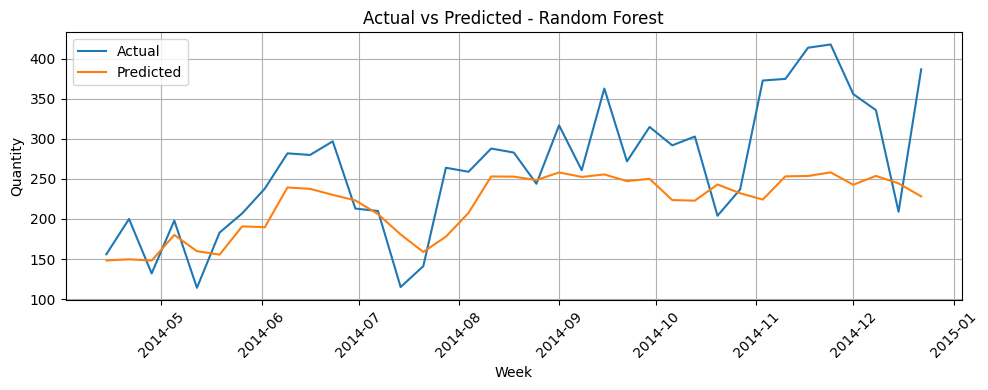

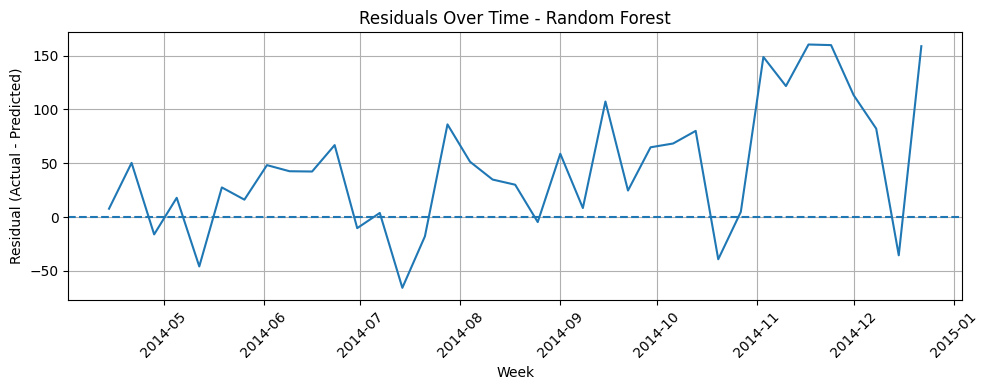

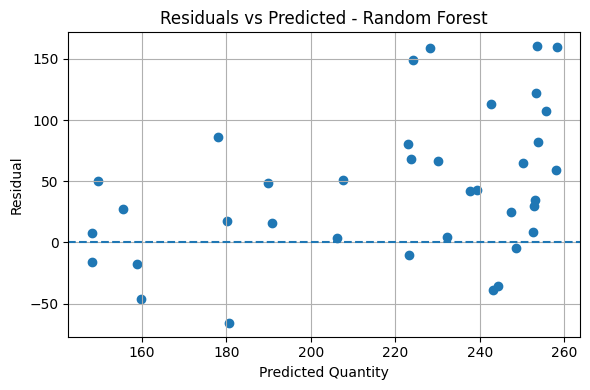

=== Gradient Boosting ===


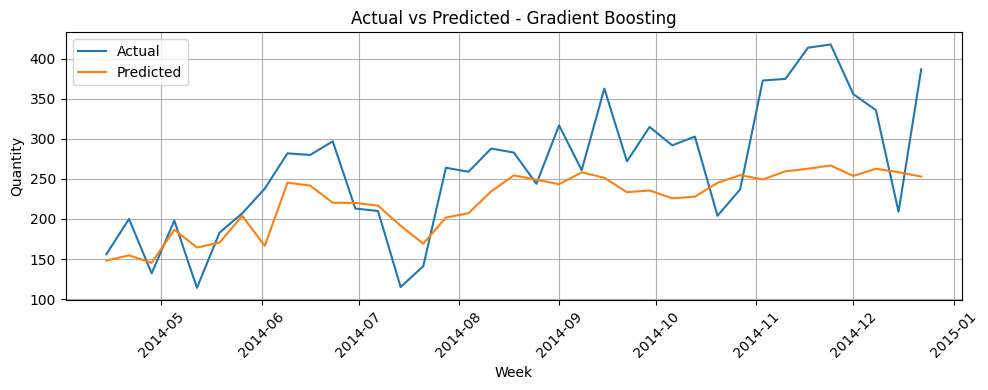

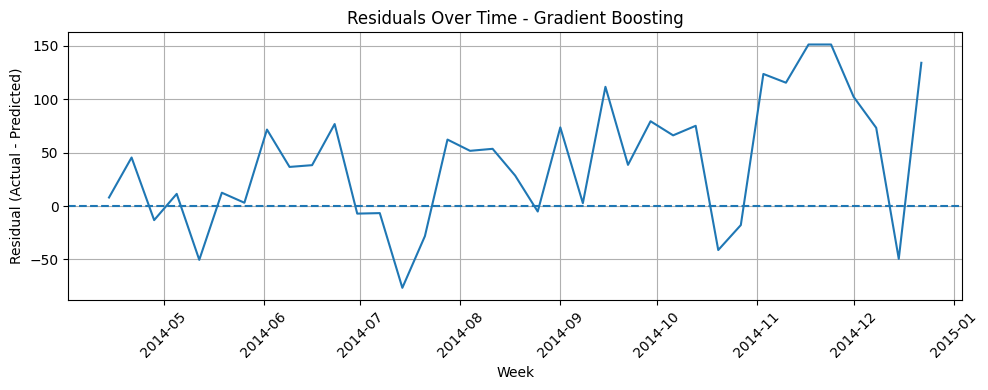

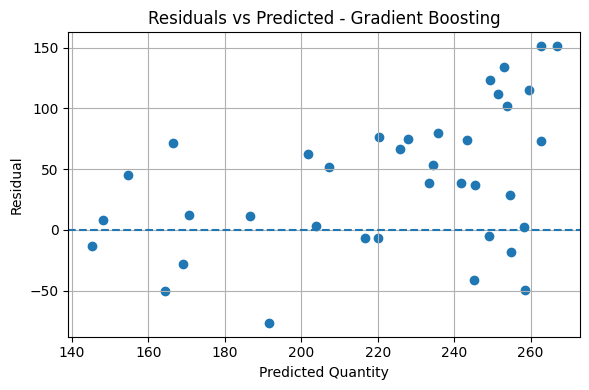

=== XGBoost ===


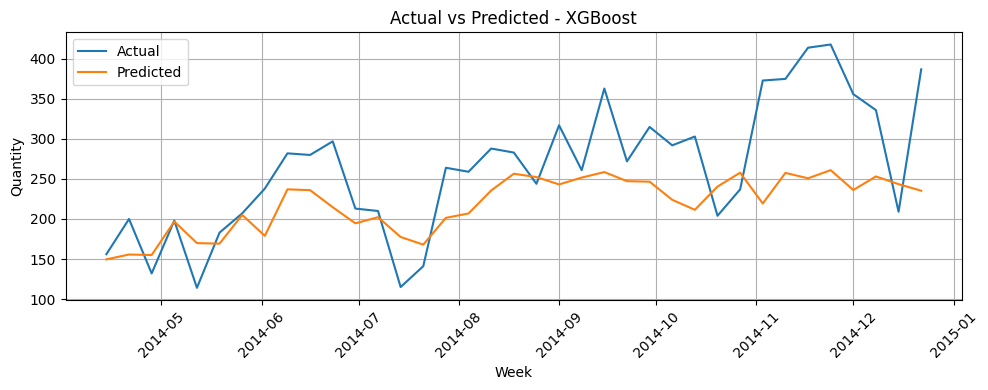

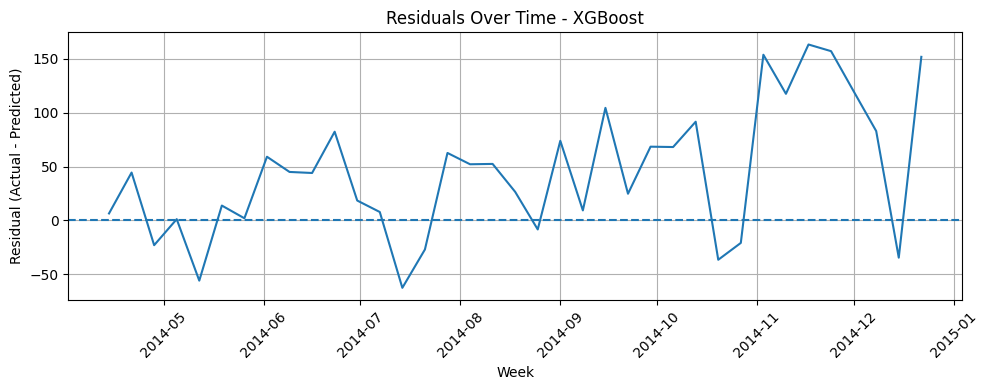

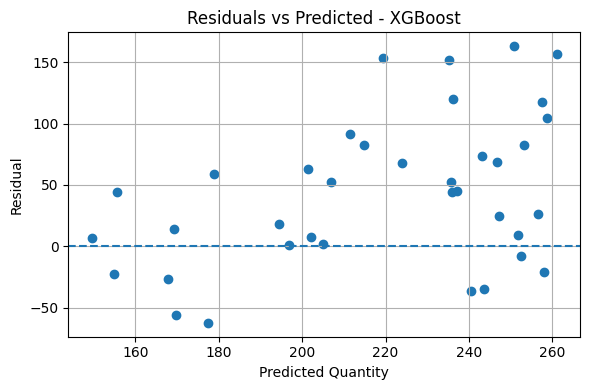

In [88]:
# === Visualize ALL models: Actual vs Predicted + Residuals ===

for model_name, model_preds in preds_test.items():
    print(f"=== {model_name} ===")
    residuals = y_test - model_preds

    # Actual vs Predicted
    plt.figure(figsize=(10, 4))
    plt.plot(dates_test, y_test.values, label="Actual")
    plt.plot(dates_test, model_preds, label="Predicted")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.xlabel("Week")
    plt.ylabel("Quantity")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Residuals over time
    plt.figure(figsize=(10, 4))
    plt.plot(dates_test, residuals)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residuals Over Time - {model_name}")
    plt.xlabel("Week")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Residuals vs Predicted
    plt.figure(figsize=(6, 4))
    plt.scatter(model_preds, residuals)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residuals vs Predicted - {model_name}")
    plt.xlabel("Predicted Quantity")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()


In [89]:
import joblib

In [90]:
best_model = "Gradient Boosting"
print("Best model by R2:", best_model)

Best model by R2: Gradient Boosting


In [91]:
joblib.dump(best_model, "best_technology_quantity_model.joblib")
print("Model saved successfully!")

Model saved successfully!
